
Simulating hybrid functional + nonfunctional data...
Total shared observations:         500
Pre-forecast observations:         495
Forecast/test observations:        5
Functional curves shape:           (500, 100)
Nonfunctional matrix shape:        (500, 20)
Functional grid points:            100
Nonfunctional variables per row:   20
Hybrid AE latent dimension:        5
Concat PCA score dimension:        5

Row t of the functional data and row t of the nonfunctional data are the same observation.
Both are generated from the same latent AR(2) time process.


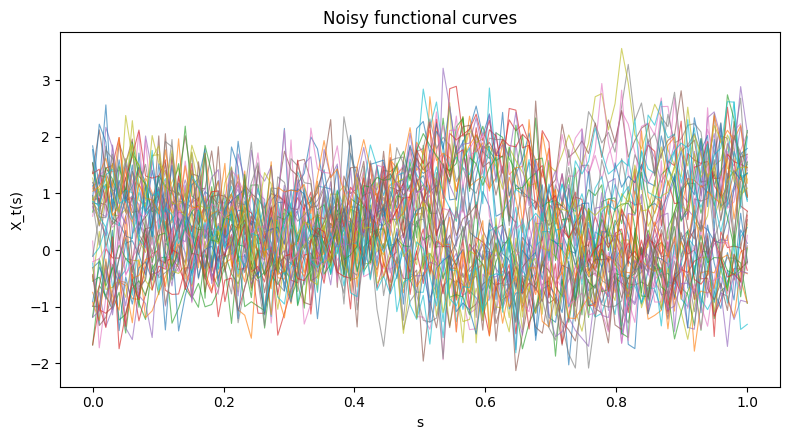

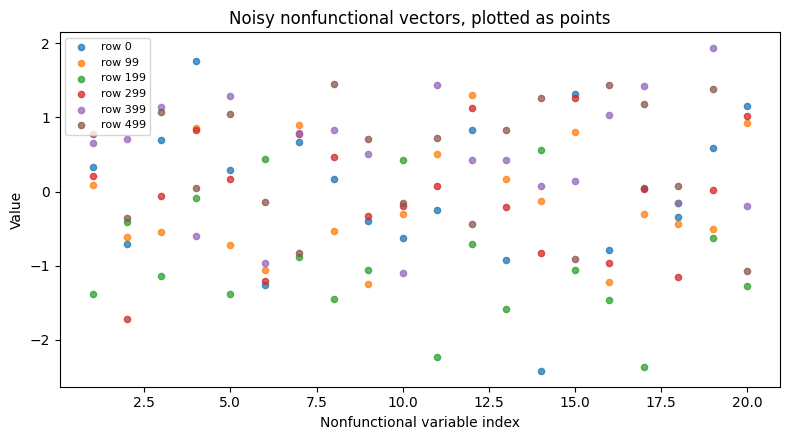


Training hybrid FAE/AE...
Epoch    1/300 | train_func=0.797495 | val_func=0.766509 | train_nonfunc=1.056228 | val_nonfunc=0.637922
Epoch  100/300 | train_func=0.243925 | val_func=0.248721 | train_nonfunc=0.166940 | val_nonfunc=0.182088
Epoch  200/300 | train_func=0.243855 | val_func=0.250375 | train_nonfunc=0.148429 | val_nonfunc=0.175318
Epoch  300/300 | train_func=0.243735 | val_func=0.255318 | train_nonfunc=0.133359 | val_nonfunc=0.177352


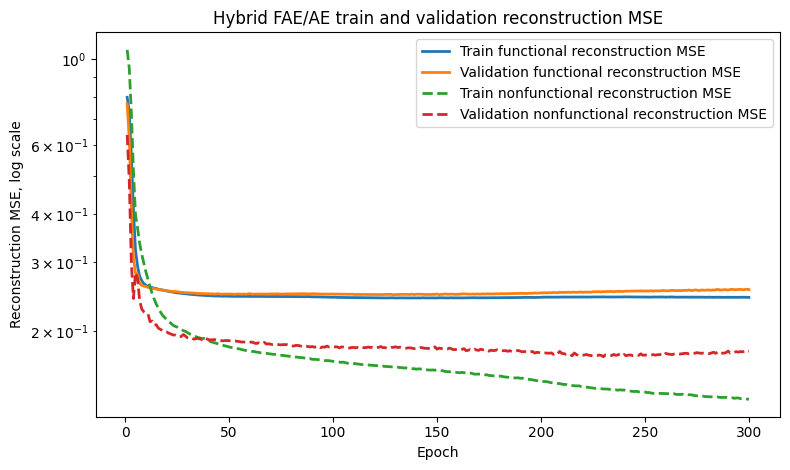


Hybrid FAE/AE reconstruction MSE
Functional centered noisy scale:    0.245263
Nonfunctional standardized scale:   0.139293

Fitting VAR model to hybrid FAE/AE latent scores...
Hybrid FAE/AE score model: VAR(6)
Hybrid FAE/AE score AIC:   -8.982202

Fitting concatenated FPCA/PCA baseline...
Concat FPCA/PCA score model: VAR(5)
Concat FPCA/PCA score AIC:   -10.179601
Combined PCA explained variance with K=5: 0.7262

Forecasting results
            Target                Method  Functional_MSE  Functional_RMSE  Functional_relMSE  Nonfunctional_MSE  Nonfunctional_RMSE  Nonfunctional_relMSE
       Clean truth   Hybrid FAE/AE + VAR        0.011532         0.107387           0.012725           0.023799            0.154268              0.024594
       Clean truth Concat FPCA/PCA + VAR        0.053249         0.230757           0.058759           0.072054            0.268428              0.074462
Noisy observations   Hybrid FAE/AE + VAR        0.258552         0.508480           0.235617         

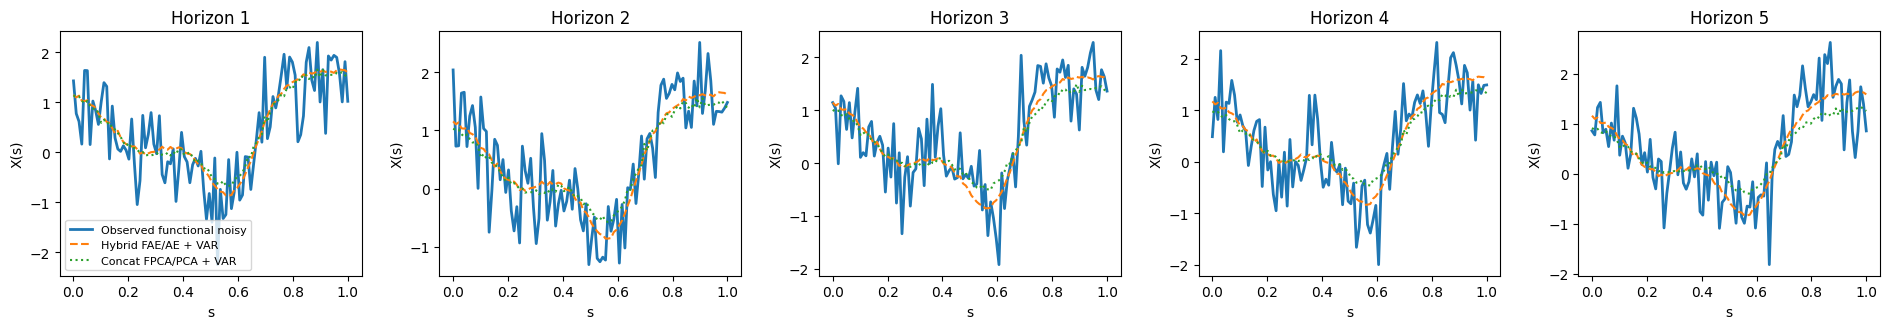

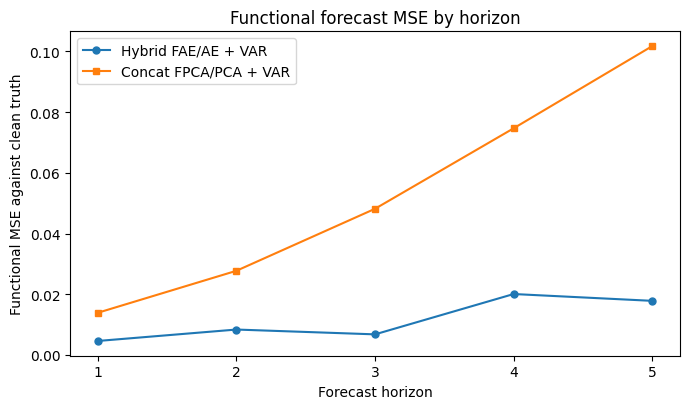

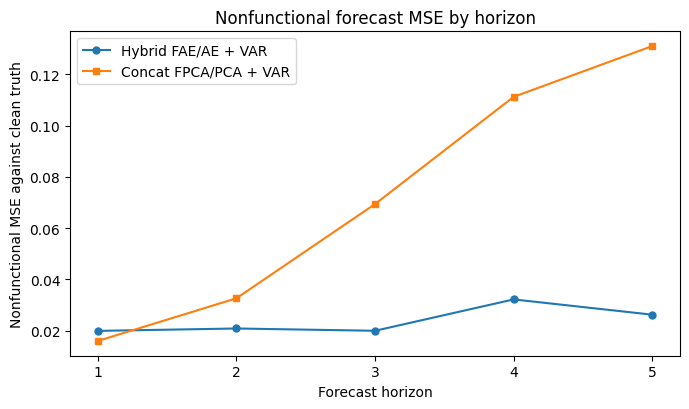

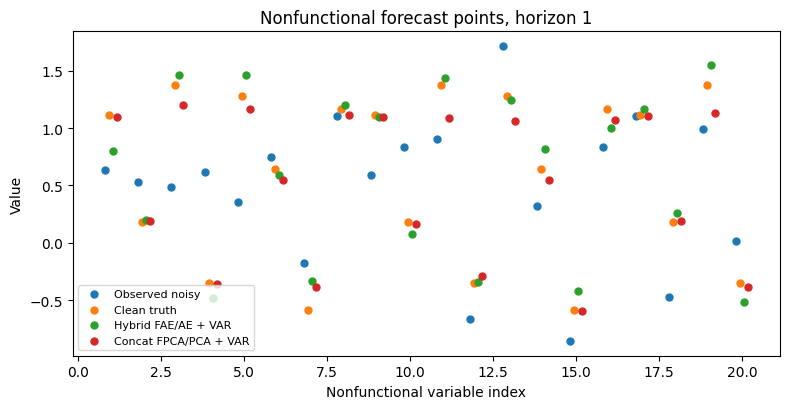

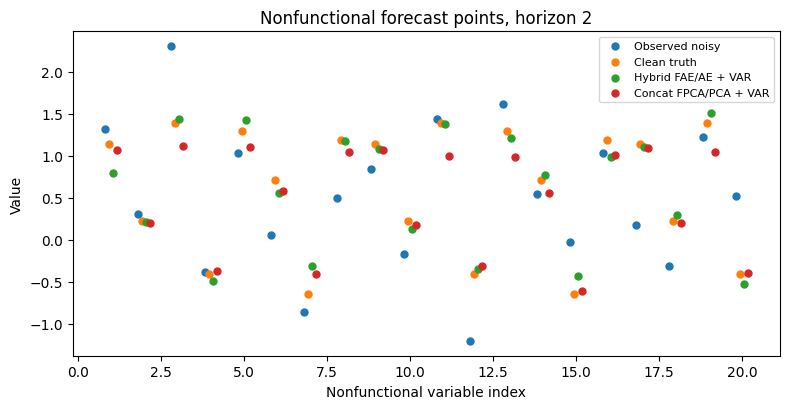

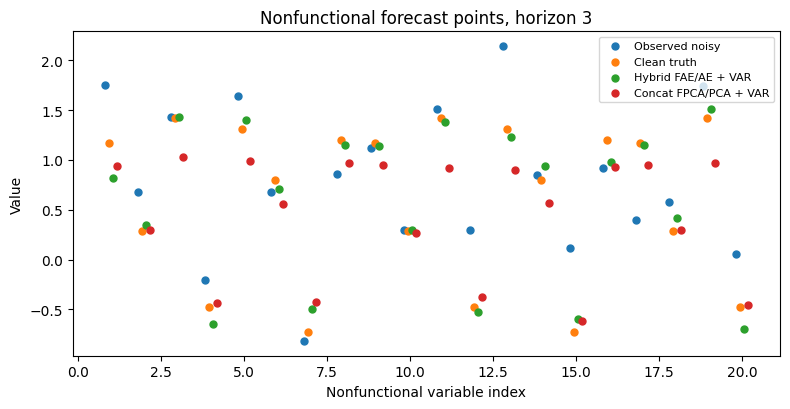

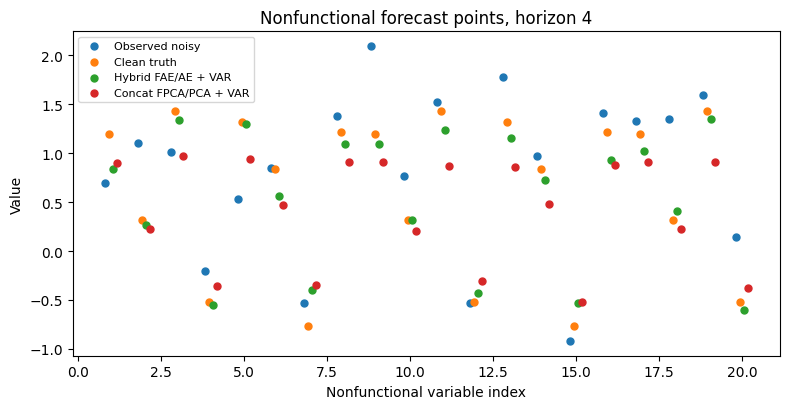

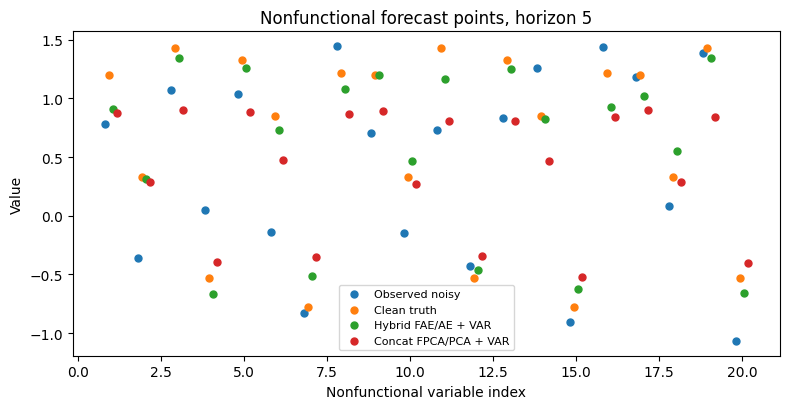

In [1]:
"""
Hybrid functional + nonfunctional time-series simulation:

Hybrid FAE/AE:
    functional curve -> FAE branch with B-spline decoder + smoothness penalty
    nonfunctional vector -> simple AE branch with no smoothing
    both branches fuse into one shared latent space
    VAR forecasting is applied to the shared latent space

Baseline:
    concatenate functional data and nonfunctional data first
    run PCA on the combined hybrid matrix
    VAR forecasting is applied to the combined PCA score space

Nothing is saved to disk.
"""

from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.interpolate import BSpline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from torch import optim
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Config
# ============================================================

@dataclass
class Config:
    n_time: int = 500
    n_grid: int = 100

    forecast_horizon: int = 5

    # Functional noise
    noise_sd: float = 0.5

    # Nonfunctional data: each observation has a vector of length 20.
    n_nonfunctional: int = 20
    nonfunctional_noise_sd: float = 0.5

    # Shared latent dimension for Hybrid FAE/AE.
    # Also number of combined PCA scores in the baseline.
    latent_dim: int = 5

    n_basis: int = 35
    hidden_width: int = 64
    nonfunctional_hidden_width: int = 64

    epochs: int = 300
    batch_size: int = 64
    learning_rate: float = 1e-3
    weight_decay: float = 1e-6

    # Smoothness applies only to the functional decoder coefficients.
    smooth_lambda: float = 0.01

    # Weight for nonfunctional reconstruction loss.
    nonfunctional_loss_weight: float = 1.0

    validation_fraction: float = 0.15

    max_ar_lags: int = 8
    seed: int = 743


CFG = Config()


# ============================================================
# Utilities
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)


def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)
    return float(np.mean((pred - truth) ** 2))


def rmse(pred, truth) -> float:
    return float(np.sqrt(mse(pred, truth)))


def relative_mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)
    denom = np.mean(truth ** 2)
    return float(np.mean((pred - truth) ** 2) / denom)


# ============================================================
# Simulation
# ============================================================

def simulate_latent_ar2(n_time: int, seed: int) -> np.ndarray:
    """
    One-dimensional AR(2) latent process.

    This same latent process drives:
        1. the functional curves
        2. the nonfunctional vectors

    So row t of the functional data and row t of the nonfunctional data
    belong to the same observation.
    """
    rng = np.random.default_rng(seed)
    burn = 200

    period = 90.0
    omega = 2.0 * np.pi / period
    rho = 0.995

    a1 = 2.0 * rho * np.cos(omega)
    a2 = -rho ** 2

    innovation_sd = 0.025

    z = np.zeros(n_time + burn)
    z[0] = rng.normal()
    z[1] = rng.normal()

    for t in range(2, n_time + burn):
        z[t] = a1 * z[t - 1] + a2 * z[t - 2] + rng.normal(0.0, innovation_sd)

    z = z[burn:]
    z = (z - z.mean()) / z.std()

    return z.reshape(-1, 1).astype(np.float32)


def nonlinear_curve_decoder(z: np.ndarray, s: np.ndarray) -> np.ndarray:
    """
    Nonlinear latent-to-functional-curve map.
    """
    z1 = z[:, 0]
    n_time = len(z1)
    n_grid = len(s)

    x = np.zeros((n_time, n_grid), dtype=np.float32)

    mean_curve = 0.20 + 0.35 * s - 0.10 * (s - 0.5) ** 2

    for t in range(n_time):
        phase = 0.32 * np.tanh(1.10 * z1[t])
        center = 0.50 + 0.28 * np.tanh(0.90 * z1[t])
        height = 0.85 * np.tanh(1.20 * z1[t])
        width = 0.060

        bump = height * np.exp(-0.5 * ((s - center) / width) ** 2)
        wave1 = np.sin(2.0 * np.pi * (s + phase))
        wave2 = 0.40 * np.cos(4.0 * np.pi * (s + 0.45 * phase))
        wave3 = 0.18 * np.sin(6.0 * np.pi * s) * np.tanh(z1[t])

        x[t] = mean_curve + wave1 + wave2 + wave3 + bump

    return x


def simulate_nonfunctional_data_from_latent(
    z: np.ndarray,
    n_nonfunctional: int,
    seed: int,
) -> np.ndarray:
    """
    Nonfunctional data generated from the same latent process.

    Each row is a 20-dimensional vector.
    This is not a curve and has no grid/function structure.

    Shape:
        y_clean: [n_time, n_nonfunctional]
    """
    rng = np.random.default_rng(seed)

    z1 = z[:, 0]
    n_time = len(z1)

    base_features = [
        z1,
        z1 ** 2,
        np.sin(z1),
        np.cos(z1),
        np.tanh(z1),
        z1 * np.sin(z1),
        np.exp(-0.5 * z1 ** 2),
        np.sign(z1) * np.sqrt(np.abs(z1) + 1e-8),
    ]

    y = np.zeros((n_time, n_nonfunctional), dtype=np.float32)

    for j in range(n_nonfunctional):
        base = base_features[j % len(base_features)]

        scale = rng.normal(1.0, 0.20)
        shift = rng.normal(0.0, 0.25)

        y[:, j] = scale * base + shift

    # Standardize clean nonfunctional variables.
    y = (y - y.mean(axis=0, keepdims=True)) / y.std(axis=0, keepdims=True)

    return y.astype(np.float32)


def simulate_hybrid_ts(
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    s = np.linspace(0.0, 1.0, cfg.n_grid).astype(np.float32)

    z = simulate_latent_ar2(cfg.n_time, cfg.seed)

    x_clean = nonlinear_curve_decoder(z, s)

    y_clean = simulate_nonfunctional_data_from_latent(
        z=z,
        n_nonfunctional=cfg.n_nonfunctional,
        seed=cfg.seed + 2000,
    )

    rng = np.random.default_rng(cfg.seed + 1000)

    x_noisy = x_clean + rng.normal(
        0.0,
        cfg.noise_sd,
        size=x_clean.shape,
    ).astype(np.float32)

    y_noisy = y_clean + rng.normal(
        0.0,
        cfg.nonfunctional_noise_sd,
        size=y_clean.shape,
    ).astype(np.float32)

    return (
        s,
        x_clean.astype(np.float32),
        x_noisy.astype(np.float32),
        y_clean.astype(np.float32),
        y_noisy.astype(np.float32),
        z.astype(np.float32),
    )


# ============================================================
# B-spline basis
# ============================================================

def make_bspline_basis(
    t_grid: np.ndarray,
    n_basis: int,
    degree: int = 3,
) -> torch.Tensor:
    t_grid = np.asarray(t_grid, dtype=float)

    a = float(t_grid.min())
    b = float(t_grid.max())

    if n_basis <= degree:
        raise ValueError("n_basis must be larger than degree.")

    n_interior = n_basis - degree - 1

    if n_interior > 0:
        interior = np.linspace(a, b, n_interior + 2)[1:-1]
    else:
        interior = np.array([])

    knots = np.concatenate([
        np.repeat(a, degree + 1),
        interior,
        np.repeat(b, degree + 1),
    ])

    basis = []

    for i in range(n_basis):
        c = np.zeros(n_basis)
        c[i] = 1.0

        spline = BSpline(
            knots,
            c,
            degree,
            extrapolate=False,
        )

        values = spline(t_grid)

        values = np.nan_to_num(
            values,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        basis.append(values)

    return torch.tensor(
        np.vstack(basis),
        dtype=torch.float32,
    )


# ============================================================
# Hybrid FAE + AE
# ============================================================

class HybridFAEAE(nn.Module):
    """
    Hybrid model.

    Functional branch:
        functional curve -> nonlinear encoder

    Nonfunctional branch:
        20-dimensional vector -> simple AE encoder

    Fusion:
        concatenate branch representations -> shared latent vector

    Decoders:
        shared latent -> functional B-spline decoder
        shared latent -> nonfunctional vector decoder

    Smoothness penalty is applied only to the functional decoder coefficients.
    """

    def __init__(
        self,
        n_grid: int,
        n_nonfunctional: int,
        latent_dim: int,
        hidden_width: int,
        nonfunctional_hidden_width: int,
        n_basis: int,
        basis: torch.Tensor,
    ):
        super().__init__()

        self.functional_encoder = nn.Sequential(
            nn.Linear(n_grid, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, latent_dim),
        )

        self.nonfunctional_encoder = nn.Sequential(
            nn.Linear(n_nonfunctional, nonfunctional_hidden_width),
            nn.Tanh(),
            nn.Linear(nonfunctional_hidden_width, nonfunctional_hidden_width),
            nn.Tanh(),
            nn.Linear(nonfunctional_hidden_width, latent_dim),
        )

        self.fusion = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, latent_dim),
        )

        self.functional_decoder_to_coef = nn.Sequential(
            nn.Linear(latent_dim, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, n_basis),
        )

        self.nonfunctional_decoder = nn.Sequential(
            nn.Linear(latent_dim, nonfunctional_hidden_width),
            nn.Tanh(),
            nn.Linear(nonfunctional_hidden_width, nonfunctional_hidden_width),
            nn.Tanh(),
            nn.Linear(nonfunctional_hidden_width, n_nonfunctional),
        )

        self.register_buffer("basis", basis)

    def encode(
        self,
        x_func: torch.Tensor,
        y_nonfunc: torch.Tensor,
    ) -> torch.Tensor:
        h_func = self.functional_encoder(x_func)
        h_nonfunc = self.nonfunctional_encoder(y_nonfunc)

        h = self.fusion(
            torch.cat([h_func, h_nonfunc], dim=1)
        )

        return h

    def decode_latent(
        self,
        h: torch.Tensor,
    ):
        coef = self.functional_decoder_to_coef(h)
        x_hat = torch.matmul(coef, self.basis)

        y_hat = self.nonfunctional_decoder(h)

        return x_hat, coef, y_hat

    def forward(
        self,
        x_func: torch.Tensor,
        y_nonfunc: torch.Tensor,
    ):
        h = self.encode(x_func, y_nonfunc)
        x_hat, coef, y_hat = self.decode_latent(h)

        return x_hat, y_hat, h, coef


# ============================================================
# Splitting
# ============================================================

def chronological_train_validation_split_two(
    x: np.ndarray,
    y: np.ndarray,
    validation_fraction: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n_total = x.shape[0]

    n_val = int(round(validation_fraction * n_total))
    n_val = max(1, n_val)
    n_val = min(n_val, n_total - 1)

    x_train = x[:-n_val]
    x_val = x[-n_val:]

    y_train = y[:-n_val]
    y_val = y[-n_val:]

    return x_train, x_val, y_train, y_val


# ============================================================
# Hybrid training
# ============================================================

def hybrid_batch_losses(
    model: nn.Module,
    x_batch: torch.Tensor,
    y_batch: torch.Tensor,
    cfg: Config,
    mse_loss: nn.Module,
):
    x_hat, y_hat, h, coef = model(x_batch, y_batch)

    functional_recon = mse_loss(x_hat, x_batch)
    nonfunctional_recon = mse_loss(y_hat, y_batch)

    # Smoothness only for functional decoder coefficients.
    second_diff = coef[:, 2:] - 2.0 * coef[:, 1:-1] + coef[:, :-2]
    smooth_penalty = torch.mean(torch.sum(second_diff ** 2, dim=1))

    recon_loss = functional_recon + cfg.nonfunctional_loss_weight * nonfunctional_recon

    total_loss = recon_loss + cfg.smooth_lambda * smooth_penalty

    return total_loss, functional_recon, nonfunctional_recon, smooth_penalty


def evaluate_hybrid_loss(
    model: nn.Module,
    x_data: torch.Tensor,
    y_data: torch.Tensor,
    cfg: Config,
    device: torch.device,
):
    loader = DataLoader(
        TensorDataset(x_data, y_data),
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
    )

    mse_loss = nn.MSELoss()

    total_sum = 0.0
    functional_sum = 0.0
    nonfunctional_sum = 0.0
    smooth_sum = 0.0
    n_seen = 0

    model.eval()

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            total, functional_recon, nonfunctional_recon, smooth = hybrid_batch_losses(
                model,
                x_batch,
                y_batch,
                cfg,
                mse_loss,
            )

            bs = x_batch.shape[0]

            total_sum += total.item() * bs
            functional_sum += functional_recon.item() * bs
            nonfunctional_sum += nonfunctional_recon.item() * bs
            smooth_sum += smooth.item() * bs
            n_seen += bs

    return {
        "total": total_sum / n_seen,
        "functional_recon": functional_sum / n_seen,
        "nonfunctional_recon": nonfunctional_sum / n_seen,
        "smooth": smooth_sum / n_seen,
    }


def train_hybrid_ae(
    model: nn.Module,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    x_val: torch.Tensor,
    y_val: torch.Tensor,
    cfg: Config,
    device: torch.device,
) -> pd.DataFrame:
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False,
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    mse_loss = nn.MSELoss()

    history = []

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        total_sum = 0.0
        functional_sum = 0.0
        nonfunctional_sum = 0.0
        smooth_sum = 0.0
        n_seen = 0

        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            total, functional_recon, nonfunctional_recon, smooth = hybrid_batch_losses(
                model,
                x_batch,
                y_batch,
                cfg,
                mse_loss,
            )

            total.backward()
            optimizer.step()

            bs = x_batch.shape[0]

            total_sum += total.item() * bs
            functional_sum += functional_recon.item() * bs
            nonfunctional_sum += nonfunctional_recon.item() * bs
            smooth_sum += smooth.item() * bs
            n_seen += bs

        train_metrics = {
            "total": total_sum / n_seen,
            "functional_recon": functional_sum / n_seen,
            "nonfunctional_recon": nonfunctional_sum / n_seen,
            "smooth": smooth_sum / n_seen,
        }

        val_metrics = evaluate_hybrid_loss(
            model,
            x_val,
            y_val,
            cfg,
            device,
        )

        history.append({
            "epoch": epoch,
            "train_total": train_metrics["total"],
            "train_functional_recon": train_metrics["functional_recon"],
            "train_nonfunctional_recon": train_metrics["nonfunctional_recon"],
            "train_smooth": train_metrics["smooth"],
            "val_total": val_metrics["total"],
            "val_functional_recon": val_metrics["functional_recon"],
            "val_nonfunctional_recon": val_metrics["nonfunctional_recon"],
            "val_smooth": val_metrics["smooth"],
        })

        if epoch == 1 or epoch % 100 == 0 or epoch == cfg.epochs:
            print(
                f"Epoch {epoch:4d}/{cfg.epochs} | "
                f"train_func={train_metrics['functional_recon']:.6f} | "
                f"val_func={val_metrics['functional_recon']:.6f} | "
                f"train_nonfunc={train_metrics['nonfunctional_recon']:.6f} | "
                f"val_nonfunc={val_metrics['nonfunctional_recon']:.6f}"
            )

    return pd.DataFrame(history)


def predict_hybrid_ae(
    model: nn.Module,
    x_data: torch.Tensor,
    y_data: torch.Tensor,
    device: torch.device,
):
    model.eval()

    with torch.no_grad():
        x_data = x_data.to(device)
        y_data = y_data.to(device)

        x_hat, y_hat, h, coef = model(x_data, y_data)

        functional_mse = torch.mean((x_hat - x_data) ** 2).item()
        nonfunctional_mse = torch.mean((y_hat - y_data) ** 2).item()

    return (
        x_hat.cpu(),
        y_hat.cpu(),
        h.cpu(),
        coef.cpu(),
        functional_mse,
        nonfunctional_mse,
    )


# ============================================================
# VAR forecasting
# ============================================================

def forecast_scores_time_series(
    scores_train: np.ndarray,
    horizon: int,
    maxlags: int,
):
    """
    If score dimension is 1: AR selected by AIC.
    If score dimension > 1: VAR selected by AIC.
    """
    scaler = StandardScaler()
    scores_std = scaler.fit_transform(scores_train)

    n, k = scores_std.shape

    if k == 1:
        y = scores_std[:, 0]
        maxlags = min(maxlags, max(1, n // 8))

        best_result = None
        best_aic = np.inf
        best_lag = None

        for lag in range(1, maxlags + 1):
            try:
                result = AutoReg(y, lags=lag, old_names=False).fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_result = result
                    best_lag = lag

            except Exception:
                continue

        if best_result is None:
            raise RuntimeError("AR fitting failed for all lag choices.")

        forecast_std = best_result.predict(
            start=n,
            end=n + horizon - 1,
        ).reshape(-1, 1)

        forecast = scaler.inverse_transform(forecast_std)

        info = {
            "model": "AR",
            "lag": best_lag,
            "aic": best_aic,
        }

        return forecast, info, scaler

    safe_maxlags = min(
        maxlags,
        max(1, (n - 2) // (k + 1)),
    )

    safe_maxlags = max(1, safe_maxlags)

    last_error = None

    for pmax in range(safe_maxlags, 0, -1):
        try:
            model = VAR(scores_std)

            result = model.fit(
                maxlags=pmax,
                ic="aic",
            )

            if result.k_ar == 0:
                result = model.fit(1)

            p = result.k_ar

            forecast_std = result.forecast(
                scores_std[-p:],
                steps=horizon,
            )

            forecast = scaler.inverse_transform(forecast_std)

            info = {
                "model": "VAR",
                "lag": p,
                "aic": result.aic,
            }

            return forecast, info, scaler

        except Exception as err:
            last_error = err

    raise RuntimeError(f"VAR fitting failed. Last error: {last_error}")


# ============================================================
# Baseline: concatenate functional + nonfunctional, then PCA
# ============================================================

def concatenated_fpca_pca_forecast(
    x_train_centered: np.ndarray,
    y_train_scaled: np.ndarray,
    horizon: int,
    latent_dim: int,
    maxlags: int,
):
    """
    Baseline:

    1. Concatenate functional and nonfunctional data first.
    2. Apply PCA to the combined matrix.
    3. Forecast the combined scores with VAR.
    4. Invert PCA and split back into functional and nonfunctional sections.
    """
    n_grid = x_train_centered.shape[1]

    hybrid_train = np.concatenate(
        [x_train_centered, y_train_scaled],
        axis=1,
    )

    pca = PCA(n_components=latent_dim)

    scores_train = pca.fit_transform(hybrid_train)

    scores_forecast, info, score_scaler = forecast_scores_time_series(
        scores_train,
        horizon,
        maxlags,
    )

    hybrid_forecast = pca.inverse_transform(scores_forecast)

    x_forecast_centered = hybrid_forecast[:, :n_grid]
    y_forecast_scaled = hybrid_forecast[:, n_grid:]

    hybrid_recon_train = pca.inverse_transform(scores_train)

    x_recon_train_centered = hybrid_recon_train[:, :n_grid]
    y_recon_train_scaled = hybrid_recon_train[:, n_grid:]

    return {
        "x_forecast_centered": x_forecast_centered,
        "y_forecast_scaled": y_forecast_scaled,
        "x_recon_train_centered": x_recon_train_centered,
        "y_recon_train_scaled": y_recon_train_scaled,
        "scores_train": scores_train,
        "scores_forecast": scores_forecast,
        "pca": pca,
        "forecast_info": info,
    }


# ============================================================
# Metrics
# ============================================================

def hybrid_metric_table(
    hybrid_x_forecast,
    baseline_x_forecast,
    hybrid_y_forecast,
    baseline_y_forecast,
    x_truth,
    y_truth,
    target_name: str,
) -> pd.DataFrame:
    rows = []

    for method, x_pred, y_pred in [
        ("Hybrid FAE/AE + VAR", hybrid_x_forecast, hybrid_y_forecast),
        ("Concat FPCA/PCA + VAR", baseline_x_forecast, baseline_y_forecast),
    ]:
        rows.append({
            "Target": target_name,
            "Method": method,
            "Functional_MSE": mse(x_pred, x_truth),
            "Functional_RMSE": rmse(x_pred, x_truth),
            "Functional_relMSE": relative_mse(x_pred, x_truth),
            "Nonfunctional_MSE": mse(y_pred, y_truth),
            "Nonfunctional_RMSE": rmse(y_pred, y_truth),
            "Nonfunctional_relMSE": relative_mse(y_pred, y_truth),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plotting
# ============================================================

def plot_simulated_curves(
    s,
    x,
    n_plot: int = 35,
    title: str = "Simulated functional time series",
):
    plt.figure(figsize=(8, 4.5))

    idx = np.linspace(
        0,
        x.shape[0] - 1,
        n_plot,
        dtype=int,
    )

    for i in idx:
        plt.plot(
            s,
            x[i],
            linewidth=0.8,
            alpha=0.65,
        )

    plt.xlabel("s")
    plt.ylabel("X_t(s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_nonfunctional_points(
    y,
    n_rows: int = 6,
):
    """
    Plot nonfunctional vectors as points.

    Each selected row has 20 nonfunctional values.
    """
    n_rows = min(n_rows, y.shape[0])
    n_nonfunctional = y.shape[1]

    idx = np.linspace(
        0,
        y.shape[0] - 1,
        n_rows,
        dtype=int,
    )

    x_axis = np.arange(1, n_nonfunctional + 1)

    plt.figure(figsize=(8, 4.5))

    for row in idx:
        plt.scatter(
            x_axis,
            y[row],
            s=20,
            alpha=0.75,
            label=f"row {row}",
        )

    plt.xlabel("Nonfunctional variable index")
    plt.ylabel("Value")
    plt.title("Noisy nonfunctional vectors, plotted as points")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_training_validation_losses(
    history: pd.DataFrame,
):
    plt.figure(figsize=(8, 4.8))

    epoch = history["epoch"].to_numpy()

    plt.plot(
        epoch,
        history["train_functional_recon"],
        label="Train functional reconstruction MSE",
        linewidth=2,
    )

    plt.plot(
        epoch,
        history["val_functional_recon"],
        label="Validation functional reconstruction MSE",
        linewidth=2,
    )

    plt.plot(
        epoch,
        history["train_nonfunctional_recon"],
        linestyle="--",
        label="Train nonfunctional reconstruction MSE",
        linewidth=2,
    )

    plt.plot(
        epoch,
        history["val_nonfunctional_recon"],
        linestyle="--",
        label="Validation nonfunctional reconstruction MSE",
        linewidth=2,
    )

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction MSE, log scale")
    plt.title("Hybrid FAE/AE train and validation reconstruction MSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_forecast_curves(
    s,
    observed,
    hybrid_forecast,
    baseline_forecast,
):
    n_plot = observed.shape[0]

    n_cols = n_plot
    n_rows = 1

    plt.figure(figsize=(3.8 * n_cols, 3.4 * n_rows))

    for i in range(n_plot):
        ax = plt.subplot(n_rows, n_cols, i + 1)

        ax.plot(
            s,
            observed[i],
            label="Observed functional noisy",
            linewidth=2,
        )

        ax.plot(
            s,
            hybrid_forecast[i],
            linestyle="--",
            label="Hybrid FAE/AE + VAR",
        )

        ax.plot(
            s,
            baseline_forecast[i],
            linestyle=":",
            label="Concat FPCA/PCA + VAR",
        )

        ax.set_title(f"Horizon {i + 1}")
        ax.set_xlabel("s")
        ax.set_ylabel("X(s)")

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_functional_mse_by_horizon(
    truth,
    hybrid_forecast,
    baseline_forecast,
):
    hybrid_h = np.mean((hybrid_forecast - truth) ** 2, axis=1)
    baseline_h = np.mean((baseline_forecast - truth) ** 2, axis=1)

    horizon = np.arange(1, len(hybrid_h) + 1)

    plt.figure(figsize=(7, 4.2))

    plt.plot(
        horizon,
        hybrid_h,
        marker="o",
        markersize=5,
        label="Hybrid FAE/AE + VAR",
    )

    plt.plot(
        horizon,
        baseline_h,
        marker="s",
        markersize=5,
        label="Concat FPCA/PCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon")
    plt.ylabel("Functional MSE against clean truth")
    plt.title("Functional forecast MSE by horizon")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_nonfunctional_mse_by_horizon(
    truth,
    hybrid_forecast,
    baseline_forecast,
):
    hybrid_h = np.mean((hybrid_forecast - truth) ** 2, axis=1)
    baseline_h = np.mean((baseline_forecast - truth) ** 2, axis=1)

    horizon = np.arange(1, len(hybrid_h) + 1)

    plt.figure(figsize=(7, 4.2))

    plt.plot(
        horizon,
        hybrid_h,
        marker="o",
        markersize=5,
        label="Hybrid FAE/AE + VAR",
    )

    plt.plot(
        horizon,
        baseline_h,
        marker="s",
        markersize=5,
        label="Concat FPCA/PCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon")
    plt.ylabel("Nonfunctional MSE against clean truth")
    plt.title("Nonfunctional forecast MSE by horizon")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_nonfunctional_forecast_points(
    truth,
    observed,
    hybrid_forecast,
    baseline_forecast,
):
    """
    Plot nonfunctional forecast vectors as points.
    """
    horizon = truth.shape[0]
    n_nonfunctional = truth.shape[1]

    x_axis = np.arange(1, n_nonfunctional + 1)

    for h in range(horizon):
        plt.figure(figsize=(8, 4.2))

        plt.scatter(
            x_axis - 0.18,
            observed[h],
            s=25,
            label="Observed noisy",
        )

        plt.scatter(
            x_axis - 0.06,
            truth[h],
            s=25,
            label="Clean truth",
        )

        plt.scatter(
            x_axis + 0.06,
            hybrid_forecast[h],
            s=25,
            label="Hybrid FAE/AE + VAR",
        )

        plt.scatter(
            x_axis + 0.18,
            baseline_forecast[h],
            s=25,
            label="Concat FPCA/PCA + VAR",
        )

        plt.xlabel("Nonfunctional variable index")
        plt.ylabel("Value")
        plt.title(f"Nonfunctional forecast points, horizon {h + 1}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


# ============================================================
# Main
# ============================================================

def main() -> None:
    set_seed(CFG.seed)

    device = torch.device("cpu")

    print("\nSimulating hybrid functional + nonfunctional data...")

    s, x_clean, x_noisy, y_clean, y_noisy, z_true = simulate_hybrid_ts(CFG)

    L = CFG.forecast_horizon

    # Last L rows are forecast/test rows.
    x_train_noisy_full = x_noisy[:-L]
    x_test_noisy = x_noisy[-L:]
    x_test_clean = x_clean[-L:]

    y_train_noisy_full = y_noisy[:-L]
    y_test_noisy = y_noisy[-L:]
    y_test_clean = y_clean[-L:]

    # Functional centering using only pre-forecast noisy observations.
    x_train_mean = x_train_noisy_full.mean(axis=0, keepdims=True)

    x_train_centered_full = x_train_noisy_full - x_train_mean
    x_test_centered = x_test_noisy - x_train_mean

    # Nonfunctional standardization using only pre-forecast noisy observations.
    y_scaler = StandardScaler()
    y_train_scaled_full = y_scaler.fit_transform(y_train_noisy_full)
    y_test_scaled = y_scaler.transform(y_test_noisy)

    # Chronological validation split using the same rows for both data types.
    (
        x_hybrid_train,
        x_hybrid_val,
        y_hybrid_train,
        y_hybrid_val,
    ) = chronological_train_validation_split_two(
        x_train_centered_full,
        y_train_scaled_full,
        CFG.validation_fraction,
    )

    print(f"Total shared observations:         {CFG.n_time}")
    print(f"Pre-forecast observations:         {x_train_centered_full.shape[0]}")
    print(f"Forecast/test observations:        {L}")
    print(f"Functional curves shape:           {x_noisy.shape}")
    print(f"Nonfunctional matrix shape:        {y_noisy.shape}")
    print(f"Functional grid points:            {CFG.n_grid}")
    print(f"Nonfunctional variables per row:   {CFG.n_nonfunctional}")
    print(f"Hybrid AE latent dimension:        {CFG.latent_dim}")
    print(f"Concat PCA score dimension:        {CFG.latent_dim}")
    print("\nRow t of the functional data and row t of the nonfunctional data are the same observation.")
    print("Both are generated from the same latent AR(2) time process.")

    plot_simulated_curves(
        s,
        x_noisy,
        n_plot=50,
        title="Noisy functional curves",
    )

    plot_nonfunctional_points(
        y_noisy,
        n_rows=6,
    )

    # -----------------------------
    # Hybrid FAE/AE + VAR
    # -----------------------------

    print("\nTraining hybrid FAE/AE...")

    basis = make_bspline_basis(
        s,
        CFG.n_basis,
    )

    hybrid_model = HybridFAEAE(
        n_grid=CFG.n_grid,
        n_nonfunctional=CFG.n_nonfunctional,
        latent_dim=CFG.latent_dim,
        hidden_width=CFG.hidden_width,
        nonfunctional_hidden_width=CFG.nonfunctional_hidden_width,
        n_basis=CFG.n_basis,
        basis=basis,
    ).to(device)

    x_hybrid_train_tensor = torch.tensor(
        x_hybrid_train,
        dtype=torch.float32,
    )

    x_hybrid_val_tensor = torch.tensor(
        x_hybrid_val,
        dtype=torch.float32,
    )

    y_hybrid_train_tensor = torch.tensor(
        y_hybrid_train,
        dtype=torch.float32,
    )

    y_hybrid_val_tensor = torch.tensor(
        y_hybrid_val,
        dtype=torch.float32,
    )

    x_train_full_tensor = torch.tensor(
        x_train_centered_full,
        dtype=torch.float32,
    )

    y_train_full_tensor = torch.tensor(
        y_train_scaled_full,
        dtype=torch.float32,
    )

    history = train_hybrid_ae(
        model=hybrid_model,
        x_train=x_hybrid_train_tensor,
        y_train=y_hybrid_train_tensor,
        x_val=x_hybrid_val_tensor,
        y_val=y_hybrid_val_tensor,
        cfg=CFG,
        device=device,
    )

    plot_training_validation_losses(history)

    (
        x_recon_train_hybrid,
        y_recon_train_hybrid_scaled,
        H_train_torch,
        _,
        hybrid_functional_recon_mse,
        hybrid_nonfunctional_recon_mse,
    ) = predict_hybrid_ae(
        hybrid_model,
        x_train_full_tensor,
        y_train_full_tensor,
        device,
    )

    H_train = H_train_torch.detach().cpu().numpy()

    print("\nHybrid FAE/AE reconstruction MSE")
    print(f"Functional centered noisy scale:    {hybrid_functional_recon_mse:.6f}")
    print(f"Nonfunctional standardized scale:   {hybrid_nonfunctional_recon_mse:.6f}")

    print("\nFitting VAR model to hybrid FAE/AE latent scores...")

    H_forecast, hybrid_forecast_info, _ = forecast_scores_time_series(
        H_train,
        L,
        CFG.max_ar_lags,
    )

    print(
        f"Hybrid FAE/AE score model: "
        f"{hybrid_forecast_info['model']}({hybrid_forecast_info['lag']})"
    )

    print(f"Hybrid FAE/AE score AIC:   {hybrid_forecast_info['aic']:.6f}")

    hybrid_model.eval()

    with torch.no_grad():
        H_forecast_torch = torch.tensor(
            H_forecast,
            dtype=torch.float32,
        ).to(device)

        (
            x_hybrid_forecast_centered_torch,
            _,
            y_hybrid_forecast_scaled_torch,
        ) = hybrid_model.decode_latent(H_forecast_torch)

        x_hybrid_forecast_centered = (
            x_hybrid_forecast_centered_torch
            .detach()
            .cpu()
            .numpy()
        )

        y_hybrid_forecast_scaled = (
            y_hybrid_forecast_scaled_torch
            .detach()
            .cpu()
            .numpy()
        )

    x_hybrid_forecast = x_hybrid_forecast_centered + x_train_mean
    y_hybrid_forecast = y_scaler.inverse_transform(y_hybrid_forecast_scaled)

    # -----------------------------
    # Baseline: concatenate functional + nonfunctional, then PCA + VAR
    # -----------------------------

    print("\nFitting concatenated FPCA/PCA baseline...")

    baseline_out = concatenated_fpca_pca_forecast(
        x_train_centered=x_train_centered_full,
        y_train_scaled=y_train_scaled_full,
        horizon=L,
        latent_dim=CFG.latent_dim,
        maxlags=CFG.max_ar_lags,
    )

    x_baseline_forecast = baseline_out["x_forecast_centered"] + x_train_mean

    y_baseline_forecast = y_scaler.inverse_transform(
        baseline_out["y_forecast_scaled"]
    )

    print(
        f"Concat FPCA/PCA score model: "
        f"{baseline_out['forecast_info']['model']}({baseline_out['forecast_info']['lag']})"
    )

    print(f"Concat FPCA/PCA score AIC:   {baseline_out['forecast_info']['aic']:.6f}")

    explained = float(
        np.sum(baseline_out["pca"].explained_variance_ratio_)
    )

    print(f"Combined PCA explained variance with K={CFG.latent_dim}: {explained:.4f}")

    # -----------------------------
    # Evaluation
    # -----------------------------

    summary_clean = hybrid_metric_table(
        hybrid_x_forecast=x_hybrid_forecast,
        baseline_x_forecast=x_baseline_forecast,
        hybrid_y_forecast=y_hybrid_forecast,
        baseline_y_forecast=y_baseline_forecast,
        x_truth=x_test_clean,
        y_truth=y_test_clean,
        target_name="Clean truth",
    )

    summary_noisy = hybrid_metric_table(
        hybrid_x_forecast=x_hybrid_forecast,
        baseline_x_forecast=x_baseline_forecast,
        hybrid_y_forecast=y_hybrid_forecast,
        baseline_y_forecast=y_baseline_forecast,
        x_truth=x_test_noisy,
        y_truth=y_test_noisy,
        target_name="Noisy observations",
    )

    summary = pd.concat(
        [summary_clean, summary_noisy],
        ignore_index=True,
    )

    print("\nForecasting results")
    print(
        summary.to_string(
            index=False,
            float_format=lambda v: f"{v:.6f}",
        )
    )

    # -----------------------------
    # Plots
    # -----------------------------

    plot_forecast_curves(
        s=s,
        observed=x_test_noisy,
        hybrid_forecast=x_hybrid_forecast,
        baseline_forecast=x_baseline_forecast,
    )

    plot_functional_mse_by_horizon(
        truth=x_test_clean,
        hybrid_forecast=x_hybrid_forecast,
        baseline_forecast=x_baseline_forecast,
    )

    plot_nonfunctional_mse_by_horizon(
        truth=y_test_clean,
        hybrid_forecast=y_hybrid_forecast,
        baseline_forecast=y_baseline_forecast,
    )

    plot_nonfunctional_forecast_points(
        truth=y_test_clean,
        observed=y_test_noisy,
        hybrid_forecast=y_hybrid_forecast,
        baseline_forecast=y_baseline_forecast,
    )


if __name__ == "__main__":
    main()